### Step 1: Load the Data

In [3]:
import pandas as pd

data = pd.read_csv('cleaned_diabetes_data.csv')

# the first few rows
print("First 5 rows of the dataset:")
display(data.head())

# basic info to understand data structure
print("\nDataset Information:")
data.info()

# summary statistics for numerical columns
print("\nSummary Statistics:")
display(data.describe())


First 5 rows of the dataset:


C:\Users\Owner\AppData\Local\Temp\ipykernel_24356\887937328.py:3: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('cleaned_diabetes_data.csv')


,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,...,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesmed,readmitted,emegency_history,diag
0,Caucasian,Male,35.0,87.5,1,1,7,2,44,1,...,No,No,No,No,No,Ch,Yes,NO,0,220.476667
1,Caucasian,Male,45.0,87.5,1,1,7,1,51,0,...,No,No,No,No,No,Ch,Yes,NO,0,201.333333
2,Caucasian,Male,65.0,87.5,3,1,2,4,70,1,...,No,No,No,No,No,Ch,Yes,NO,0,409.333333
3,Caucasian,Male,75.0,87.5,1,1,7,5,73,0,...,No,No,No,No,No,No,Yes,>30,0,390.000000
4,Caucasian,Female,95.0,87.5,3,3,4,12,33,3,...,No,No,No,No,No,Ch,Yes,NO,0,372.666667



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55394 entries, 0 to 55393
Data columns (total 44 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   race                      55394 non-null  object 
 1   gender                    55394 non-null  object 
 2   age                       55394 non-null  float64
 3   weight                    55394 non-null  float64
 4   admission_type_id         55394 non-null  int64  
 5   discharge_disposition_id  55394 non-null  int64  
 6   admission_source_id       55394 non-null  int64  
 7   time_in_hospital          55394 non-null  int64  
 8   num_lab_procedures        55394 non-null  int64  
 9   num_procedures            55394 non-null  int64  
 10  num_medications           55394 non-null  object 
 11  number_outpatient         55394 non-null  int64  
 12  number_inpatient          55394 non-null  int64  
 13  number_diagnoses          55394 non-nul

,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,number_outpatient,number_inpatient,number_diagnoses,emegency_history,diag
count,55394.000000,55394.0,55394.000000,55394.000000,55394.000000,55394.000000,55394.000000,55394.000000,55394.0,55394.000000,55394.000000,55394.0,55394.000000
mean,66.168538,87.5,1.761184,2.030328,4.956457,4.072878,42.840578,1.101942,0.0,0.313229,7.233672,0.0,443.754822
std,15.351660,0.0,1.095808,1.759619,2.747220,2.607855,19.037496,1.387937,0.0,0.584279,1.958164,0.0,99.519643
min,25.000000,87.5,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.0,0.000000,2.000000,0.0,164.666667
25%,55.000000,87.5,1.000000,1.000000,1.000000,2.000000,33.000000,0.000000,0.0,0.000000,6.000000,0.0,371.175000
50%,65.000000,87.5,1.000000,1.000000,7.000000,3.000000,44.000000,1.000000,0.0,0.000000,8.000000,0.0,435.333333
75%,75.000000,87.5,2.000000,3.000000,7.000000,5.000000,56.000000,2.000000,0.0,1.000000,9.000000,0.0,506.333333
max,95.000000,87.5,6.000000,8.000000,14.000000,12.000000,96.000000,5.000000,0.0,2.000000,13.000000,0.0,721.666667


### Step 2: Data Overview


In [6]:
# missing values
print("\nMissing Values in Each Column:")
display(data.isnull().sum())

# duplicate rows
print(f"\nNumber of Duplicate Rows: {data.duplicated().sum()}")

# unique values in categorical columns
print("\nUnique Values in Categorical Columns:")
for col in data.select_dtypes(include='object').columns:
    print(f"{col}: {data[col].unique()}")

# value counts for the target column 
target_column = 'readmitted'
if target_column in data.columns:
    print(f"\nValue Counts for '{target_column}':")
    display(data[target_column].value_counts())



Missing Values in Each Column:


race                        0
gender                      0
age                         0
weight                      0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_inpatient            0
number_diagnoses            0
max_glu_serum               0
a1cresult                   0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazone                0
rosiglitazone               0
acarbose                    0
miglitol                    0
troglitazone                0
tolazamide                  0
examide                     0
citoglipton                 0
insulin   


Number of Duplicate Rows: 0

Unique Values in Categorical Columns:
race: ['Caucasian' 'AfricanAmerican' 'Other' 'Hispanic' 'Asian']
gender: ['Male' 'Female' 'Unknown/Invalid']
num_medications: ['16' '8' '21' '12' '18' '17' '11' '31' '2' '23' '19' '7' '20' '14' '10'
 '22' '15' '9' '25' '13' '32' '6' '26' '24' '4' '33' '28' '5' '29' '40'
 '3' '36' '41' '27' '46' '42' '34' '35' '38' '45' '43' '1' '30' '37' '49'
 '39' '47' '44' '52' '48' '62' '54' '50' '61' '#NAME?' '55' '51' '56' '59'
 '53' '57' 12 6 9 25 8 13 15 7 18 21 11 16 27 19 20 10 22 14 5 57 29 4 23
 24 17 26 3 41 2 28 36 30 64 60 1 31 52 40 37 47 33 32 46 35 51 63 39 34
 42 38 48 59 49 43 65 68 66 54 44 58 55 45 67 79 50 53 56 61]
max_glu_serum: ['Unknown' '>300' 'Norm' '>200']
a1cresult: ['Unknown' '>7' '>8' 'Norm']
metformin: ['No' 'Steady' 'Up' 'Down']
repaglinide: ['No' 'Steady' 'Up' 'Down']
nateglinide: ['No' 'Steady' 'Up' 'Down']
chlorpropamide: ['No' 'Steady' 'Down' 'Up']
glimepiride: ['No' 'Steady' 'Up' 'Down']
acetohexa

readmitted
NO     32371
>30    17845
<30     5178
Name: count, dtype: int64

## Step 3: Exploratory Data Analysis (EDA)

### A. Exploring individual variables


#### Numeric Variables Analysis

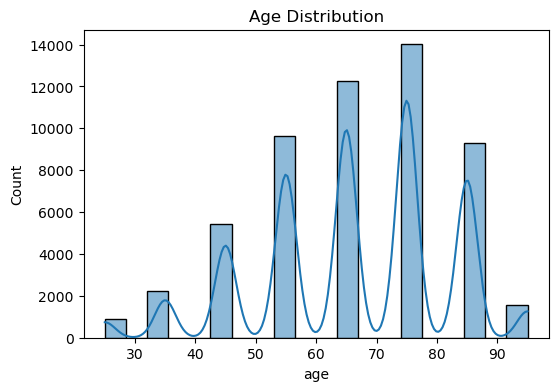

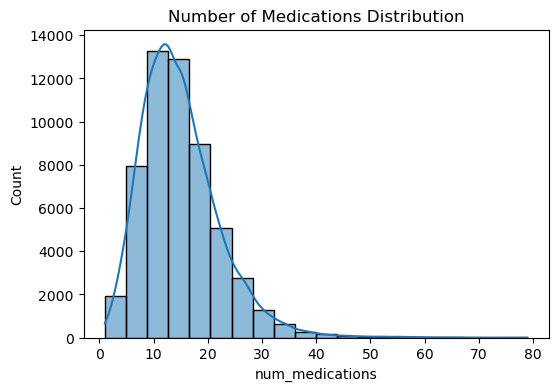

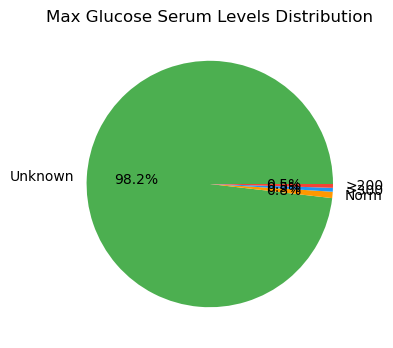

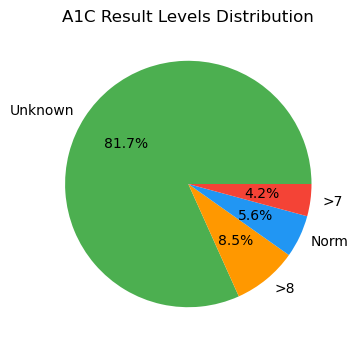

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns


# Histogram for Age Distribution
plt.figure(figsize=(6, 4))
sns.histplot(data['age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.show()

# Replace '#NAME?' with NaN
data['num_medications'] = pd.to_numeric(data['num_medications'], errors='coerce')


# Histogram for Number of Medications
plt.figure(figsize=(6, 4))
sns.histplot(data['num_medications'].astype(float), bins=20, kde=True)
plt.title('Number of Medications Distribution')
plt.show()

# Pie Chart for Glucose Levels
if 'max_glu_serum' in data.columns:
    glucose_counts = data['max_glu_serum'].value_counts()
    plt.figure(figsize=(6, 4))
    plt.pie(glucose_counts, labels=glucose_counts.index, autopct='%.1f%%', colors=['#4CAF50', '#FF9800', '#2196F3', '#F44336'])
    plt.title('Max Glucose Serum Levels Distribution')
    plt.show()

# Pie Chart for A1C Result
a1c_counts = data['a1cresult'].value_counts()
plt.figure(figsize=(6, 4))
plt.pie(a1c_counts, labels=a1c_counts.index, autopct='%.1f%%', colors=['#4CAF50', '#FF9800', '#2196F3', '#F44336'])
plt.title('A1C Result Levels Distribution')
plt.show()

#### Categorical Variables Analysis

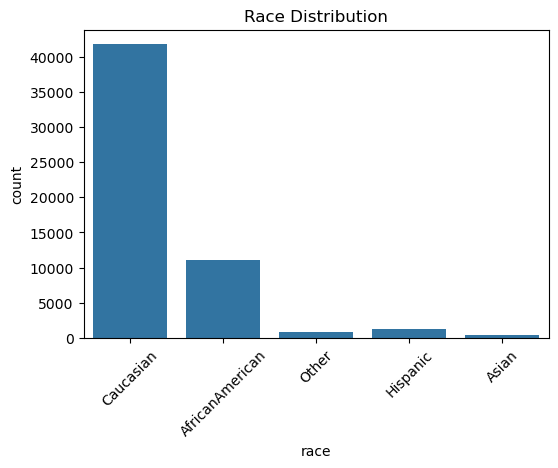

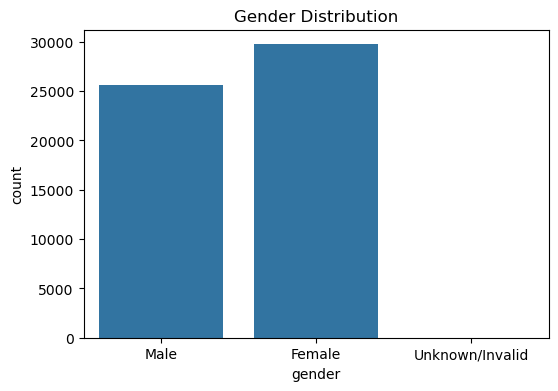

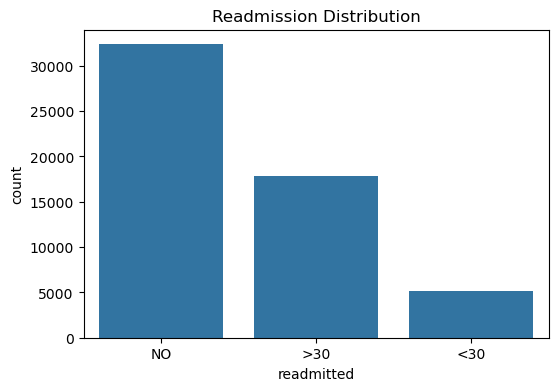

In [13]:
# Bar Chart for Race Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='race', data=data)
plt.title('Race Distribution')
plt.xticks(rotation=45)
plt.show()

# Bar Chart for Gender Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='gender', data=data)
plt.title('Gender Distribution')
plt.show()

# Bar Chart for Readmission Status
plt.figure(figsize=(6, 4))
sns.countplot(x='readmitted', data=data)
plt.title('Readmission Distribution')
plt.show()


### B. (Examining relationships between pairs of variables)


#### Correlation Heatmap (Numeric Variables)

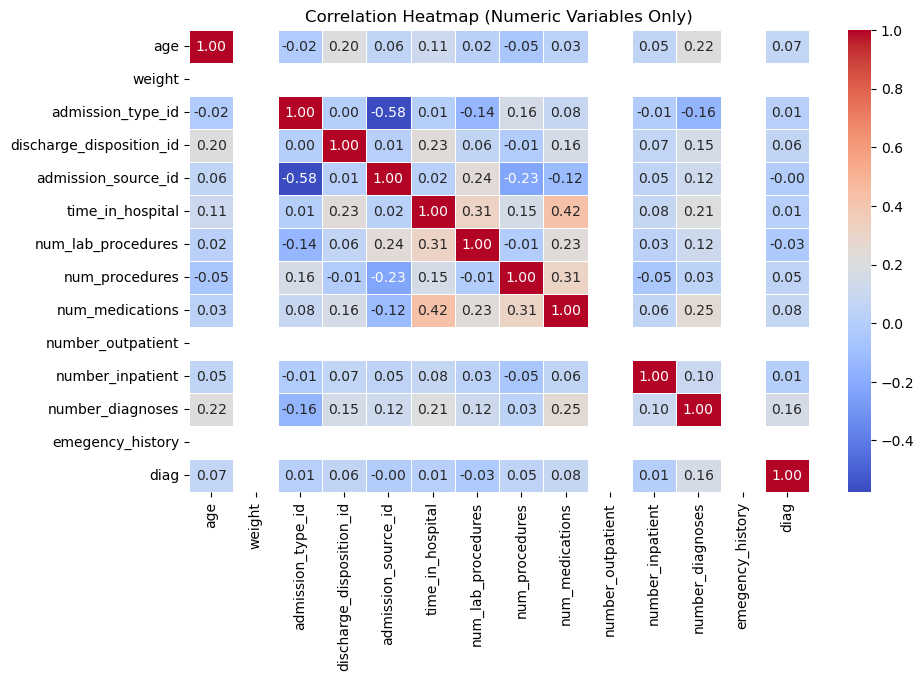

In [18]:
plt.figure(figsize=(10, 6))

# Select only numeric columns
numeric_data = data.select_dtypes(include=['float64', 'int64'])

sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap (Numeric Variables Only)')
plt.show()


#### Scatter Plots (Key Numeric Relationships)

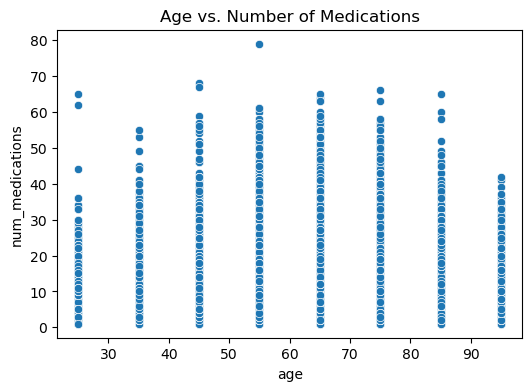

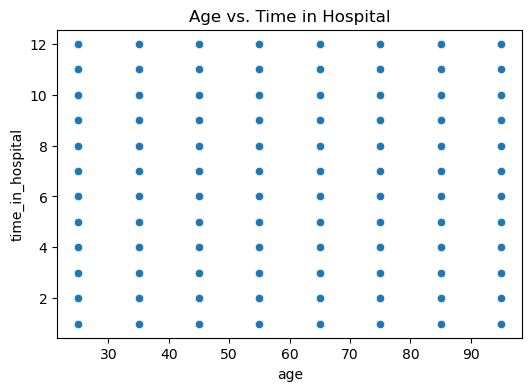

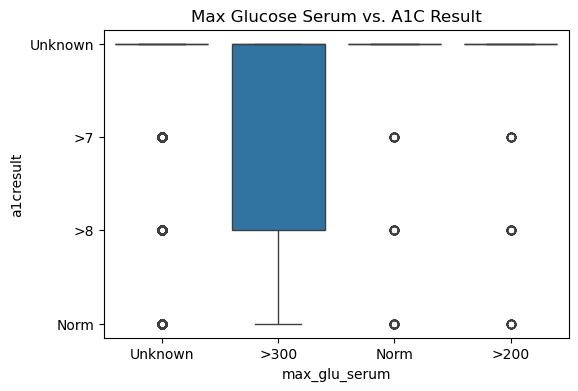

In [21]:
# Age vs. Number of Medications
plt.figure(figsize=(6, 4))
sns.scatterplot(x='age', y='num_medications', data=data)
plt.title('Age vs. Number of Medications')
plt.show()

# Age vs. Time in Hospital
plt.figure(figsize=(6, 4))
sns.scatterplot(x='age', y='time_in_hospital', data=data)
plt.title('Age vs. Time in Hospital')
plt.show()

# Max Glucose Serum vs. A1C Result (if applicable)
if 'max_glu_serum' in data.columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='max_glu_serum', y='a1cresult', data=data)
    plt.title('Max Glucose Serum vs. A1C Result')
    plt.show()


#### Categorical Analysis (Bar Charts for Comparisons)

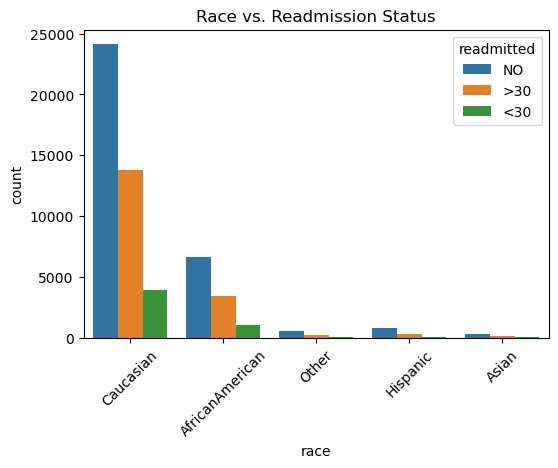

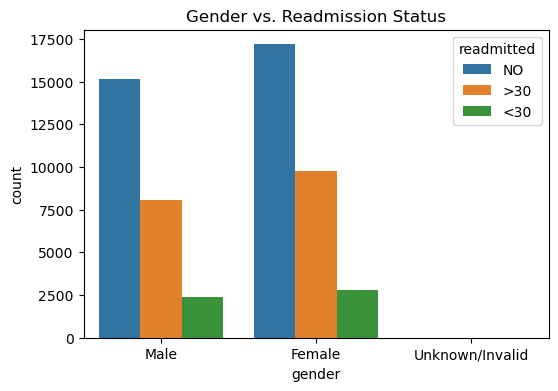

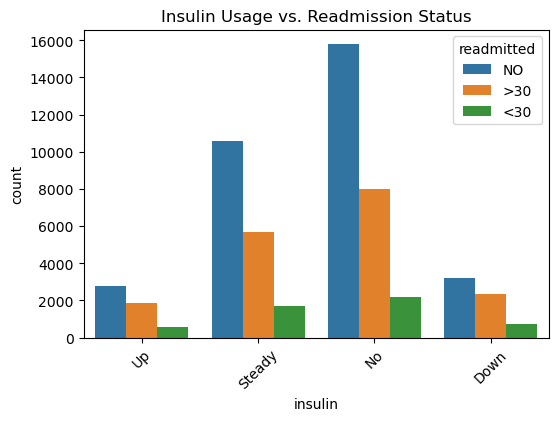

In [24]:
# Race vs. Readmission
plt.figure(figsize=(6, 4))
sns.countplot(x='race', hue='readmitted', data=data)
plt.title('Race vs. Readmission Status')
plt.xticks(rotation=45)
plt.show()

# Gender vs. Readmission
plt.figure(figsize=(6, 4))
sns.countplot(x='gender', hue='readmitted', data=data)
plt.title('Gender vs. Readmission Status')
plt.show()

# Insulin Usage vs. Readmission
plt.figure(figsize=(6, 4))
sns.countplot(x='insulin', hue='readmitted', data=data)
plt.title('Insulin Usage vs. Readmission Status')
plt.xticks(rotation=45)
plt.show()


### C. Finding deeper insights by combining multiple variables


#### Pair Plot for Multivariate Analysis

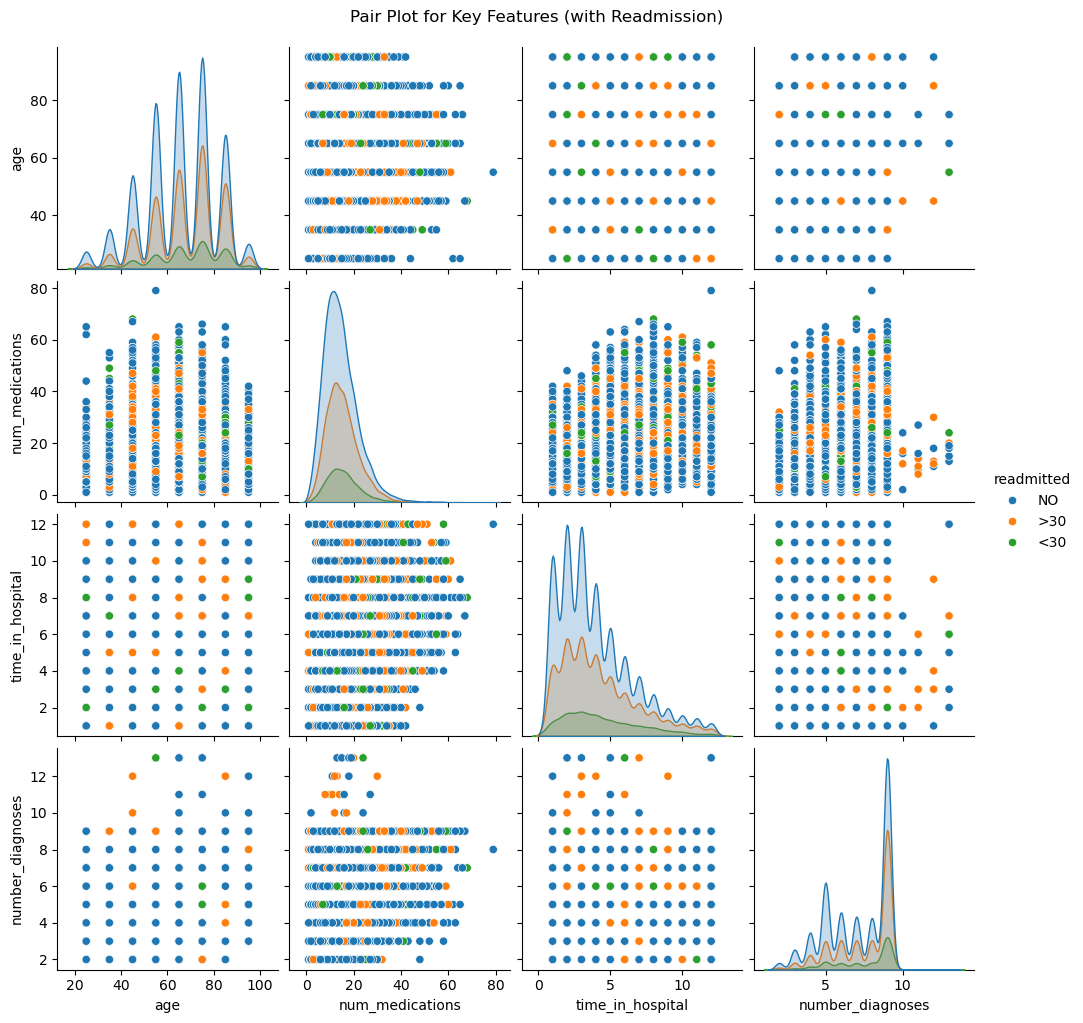

In [28]:
import seaborn as sns

# key variables for pair plot
key_features = ['age', 'num_medications', 'time_in_hospital', 'number_diagnoses']

# Pair Plot with Readmission as hue
sns.pairplot(data[key_features + ['readmitted']], hue='readmitted', diag_kind='kde')
plt.suptitle('Pair Plot for Key Features (with Readmission)', y=1.02)
plt.show()


1. Age and Readmission Status: Age does not strongly distinguish readmission groups, but older patients appear more frequently in the 'NO' group.
2. Number of Medications: A slight concentration of readmitted patients is seen in higher medication counts.
3. Time in Hospital vs. Diagnoses: Patients with more diagnoses tend to have longer hospital stays, which is common among readmitted patients.

#### Faceted Visualizations

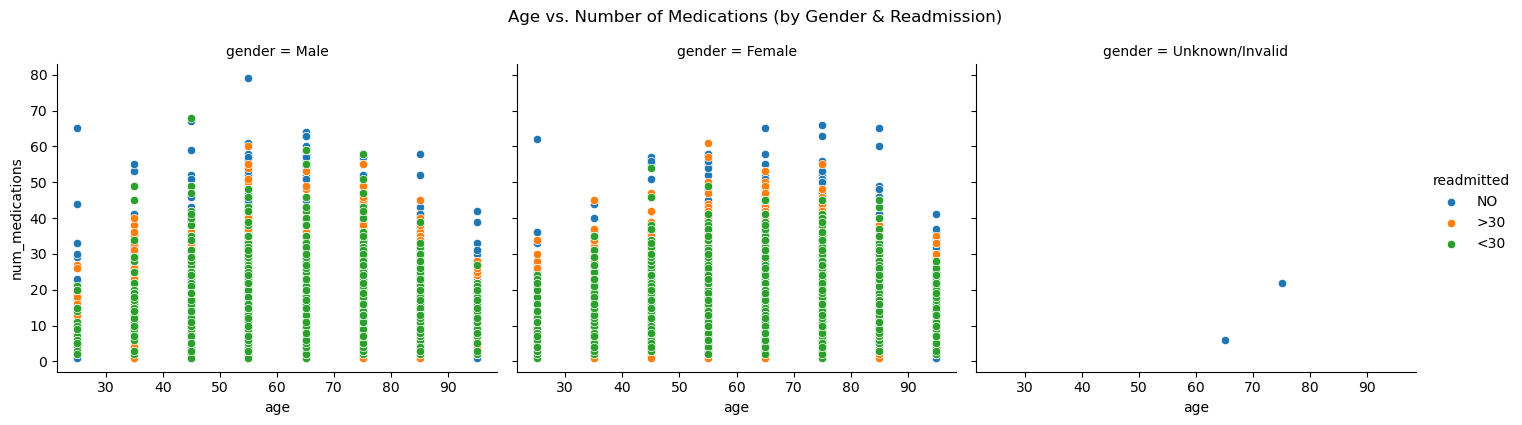

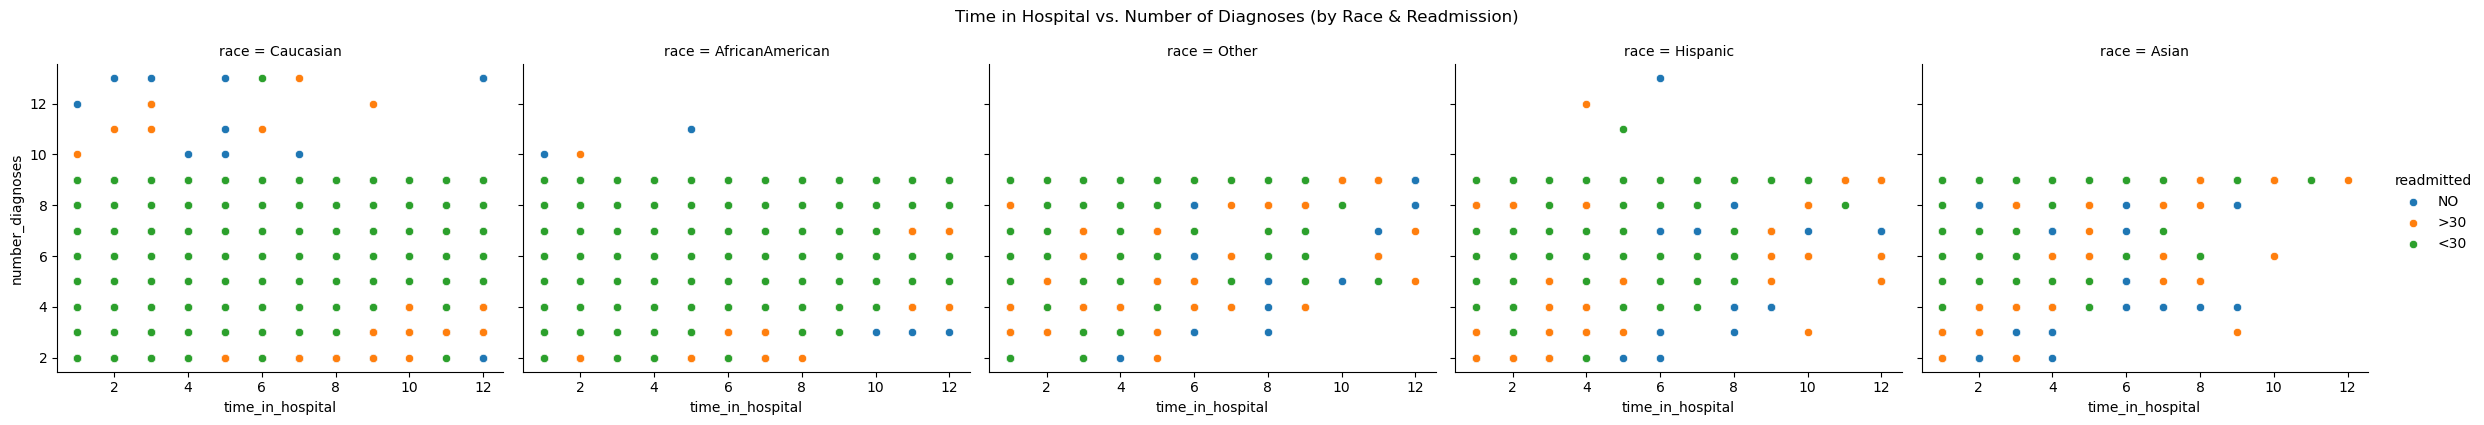

In [30]:
# Age vs. Number of Medications grouped by Gender and Readmission
g = sns.FacetGrid(data, col='gender', hue='readmitted', height=4, aspect=1.2)
g.map(sns.scatterplot, 'age', 'num_medications').add_legend()
plt.suptitle('Age vs. Number of Medications (by Gender & Readmission)', y=1.05)
plt.show()

# Time in Hospital vs. Number of Diagnoses grouped by Race
g = sns.FacetGrid(data, col='race', hue='readmitted', height=4, aspect=1.2)
g.map(sns.scatterplot, 'time_in_hospital', 'number_diagnoses').add_legend()
plt.suptitle('Time in Hospital vs. Number of Diagnoses (by Race & Readmission)', y=1.05)
plt.show()



1. *Multiple diagnoses and higher medication counts may indicate more severe cases, increasing the risk of early readmission.*
2. *Extended hospital stays correlate with a higher chance of readmission, particularly within 30 days.*
3. *Race and gender don’t appear to have a major impact, though some racial groups may show slight differences in readmission trends.*

### D. KPI Analysis (Connecting the analysis to the project’s goals)


## Step 4: KPI Analysis


### Average Age of Readmitted vs Non-Readmitted

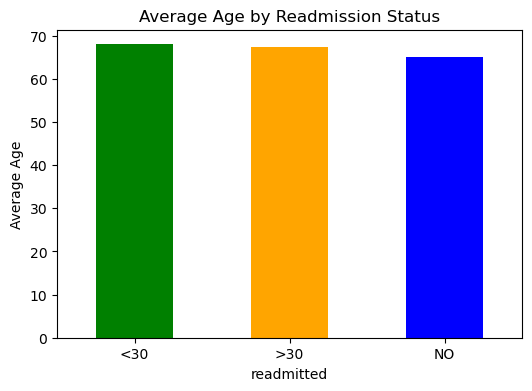

Average Age by Readmission Status:
readmitted
<30    68.037852
>30    67.458952
NO     65.158166
Name: age, dtype: float64


In [35]:
# Step 4.1 - Average Age by Readmission Status
avg_age = data.groupby('readmitted')['age'].mean()

plt.figure(figsize=(6, 4))
avg_age.plot(kind='bar', color=['green', 'orange', 'blue'])
plt.title('Average Age by Readmission Status')
plt.ylabel('Average Age')
plt.xticks(rotation=0)
plt.show()

print("Average Age by Readmission Status:")
print(avg_age)



1. Older patients (especially those around 68 years old) may be at a slightly higher risk of early readmission.
2. While the difference is not huge, it suggests that age could be a mild factor in predicting readmission risk — particularly for early readmissions (<30 days).

###  Average Number of Medications by Readmission

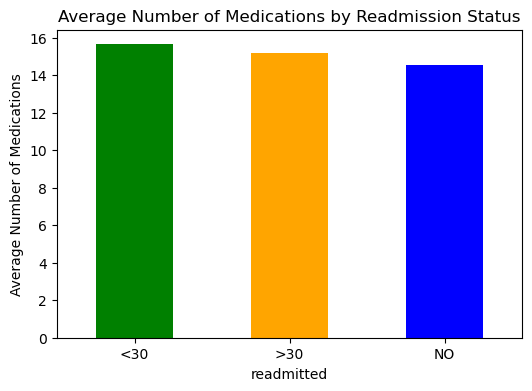

Average Number of Medications by Readmission Status:
readmitted
<30    15.648320
>30    15.204035
NO     14.556627
Name: num_medications, dtype: float64


In [38]:
avg_medications = data.groupby('readmitted')['num_medications'].mean()

plt.figure(figsize=(6, 4))
avg_medications.plot(kind='bar', color=['green', 'orange', 'blue'])
plt.title('Average Number of Medications by Readmission Status')
plt.ylabel('Average Number of Medications')
plt.xticks(rotation=0)
plt.show()

print("Average Number of Medications by Readmission Status:")
print(avg_medications)


1. The data suggests that patients with a higher number of medications are at an increased risk of early readmission (<30).
2. Managing polypharmacy (many medications) may be crucial in reducing early readmission risks.

###  Proportion of Readmissions

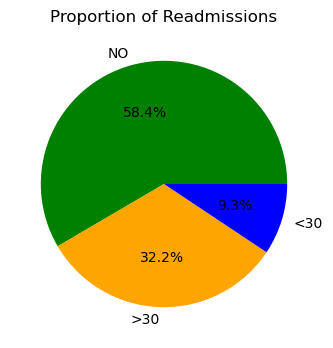

Proportion of Readmissions (%):
readmitted
NO     58.437737
>30    32.214680
<30     9.347583
Name: proportion, dtype: float64


In [41]:
readmission_counts = data['readmitted'].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 4))
readmission_counts.plot(kind='pie', autopct='%.1f%%', colors=['green', 'orange', 'blue'])
plt.title('Proportion of Readmissions')
plt.ylabel('')  # Hides the 'y-axis' label for clarity
plt.show()

print("Proportion of Readmissions (%):")
print(readmission_counts)


1. The majority of patients (58.4%) successfully avoided readmission, indicating effective treatment for many cases.
2. However, nearly 1 in 3 patients experienced a delayed readmission (>30), suggesting potential long-term care gaps.
3. Although early readmissions (<30) are the smallest group (9.3%), they are often the most concerning in healthcare settings as they may indicate treatment failure or incomplete recovery.

### Average Hospital Stay by Readmission

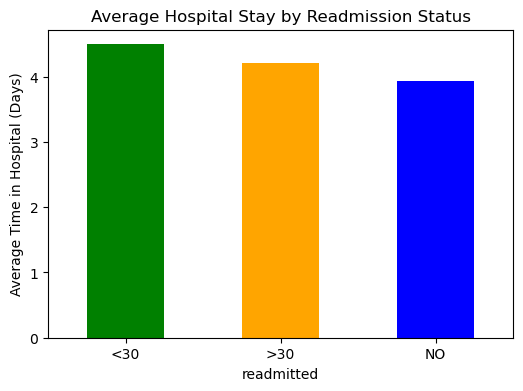

Average Hospital Stay by Readmission Status:
readmitted
<30    4.495751
>30    4.203699
NO     3.933119
Name: time_in_hospital, dtype: float64


In [44]:
avg_stay = data.groupby('readmitted')['time_in_hospital'].mean()

plt.figure(figsize=(6, 4))
avg_stay.plot(kind='bar', color=['green', 'orange', 'blue'])
plt.title('Average Hospital Stay by Readmission Status')
plt.ylabel('Average Time in Hospital (Days)')
plt.xticks(rotation=0)
plt.show()

print("Average Hospital Stay by Readmission Status:")
print(avg_stay)


1. There’s a clear pattern where longer hospital stays are linked to a higher risk of readmission, especially for early readmissions (<30).
2. Patients requiring extended care may have more complex conditions, contributing to their increased risk of being readmitted soon after discharge.

### A1C Result Analysis by Readmission

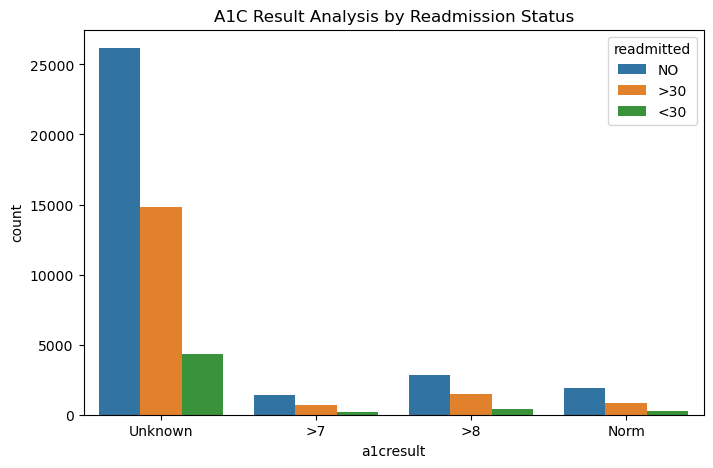

In [47]:
plt.figure(figsize=(8, 5))
sns.countplot(x='a1cresult', hue='readmitted', data=data)
plt.title('A1C Result Analysis by Readmission Status')
plt.xticks(rotation=0)
plt.show()


1. The large number of 'Unknown' values limits the ability to draw precise conclusions from this feature alone.
2. However, among the recorded results, higher A1C values correlate with a higher risk of readmission, which aligns with diabetes management challenges.

### Glucose Level Analysis by Readmission

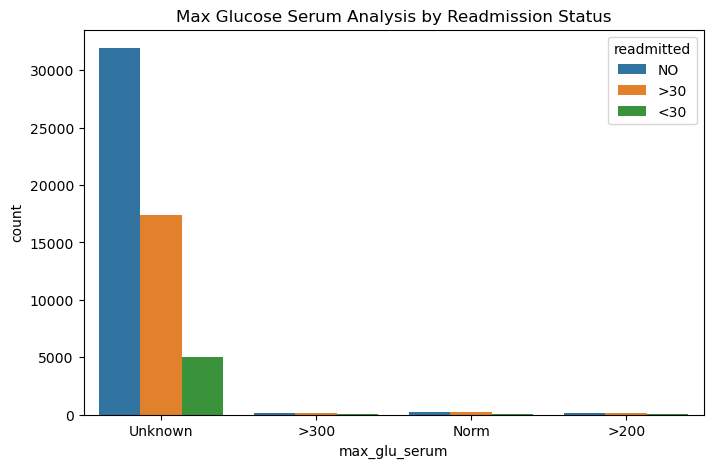

In [50]:
plt.figure(figsize=(8, 5))
sns.countplot(x='max_glu_serum', hue='readmitted', data=data)
plt.title('Max Glucose Serum Analysis by Readmission Status')
plt.xticks(rotation=0)
plt.show()


1. The dominance of 'Unknown' values reduces the effectiveness of this feature for predicting readmissions.
2. However, among recorded values, elevated glucose levels (>300 or >200) may signal a higher risk of readmission, reinforcing the importance of glucose management.

# Conclusion
1. Age Factor:
Older patients (~68 years) are slightly more prone to early readmission (<30).
2. Medications:
Patients with 15 or more medications have a higher risk of readmission.
3. Readmission Proportions:
9.3% were readmitted within 30 days (<30).
32.2% were readmitted after 30 days (>30).
58.4% were not readmitted.
4. Hospital Stay Duration:
Longer hospital stays correlate with higher readmission rates.
5. A1C Results:
Higher A1C values (>7 or >8) show a greater risk of readmission.
6. Glucose Levels:
Elevated glucose levels (>300 or >200) are linked to higher readmission rates.
7. Data Gaps:
A significant number of 'Unknown' values in A1C and glucose data may limit deeper insights.
Recommendations
### points to learn
* Focus on older patients (especially 65+) for enhanced follow-up care.
* Pay closer attention to patients on 15+ medications to reduce readmission risks.
* Implement targeted support programs for patients with longer hospital stays.
* Improve A1C and glucose monitoring for better early detection and intervention.
* Address gaps in data by improving documentation of A1C results and glucose levels.
* Develop targeted intervention strategies for patients with high A1C values or elevated glucose to reduce complications.